In [106]:
from pathlib import Path

# Find repo root
REPO_ROOT = Path.cwd().parent
print(f"Repo root: {REPO_ROOT}")

REPORT_ROOT = REPO_ROOT / "report"

Repo root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling


In [107]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import sys
import json
from shapely.geometry import shape
from hotelling.spatial.admin import join_lor_names

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from hotelling.spatial.boundaries import load_boundary

PATH_RAW = REPO_ROOT / Path('data/raw')
PATH_PROCESSED = REPO_ROOT / Path('data/processed')

# Midpoint table (center coordinates)
zensus = gpd.read_parquet(PATH_RAW / 'zensus2022_grid.parquet')
zensus_filtered = gpd.read_parquet(PATH_RAW / 'zensus2022_grid_filtered.parquet')
lor = gpd.read_parquet(PATH_PROCESSED / 'lor.parquet')

# CRITICAL FIX: berlin.geojson has EPSG:3035 coordinates but geopandas auto-detects as EPSG:4326
# We must force the correct CRS instead of transforming from the wrong one
with open(PATH_RAW / 'city_boundary_Berlin.geojson', 'r') as f:
    berlin_json = json.load(f)
berlin = gpd.GeoDataFrame([1], geometry=[shape(berlin_json['geometry'])], crs='EPSG:3035')

boundary = load_boundary(PATH_RAW / 'relation_boundary_14983.geojson')

In [108]:
from shapely.geometry import box, shape

# Work in original EPSG:3035 projection (meters)
zensus_3035 = zensus_filtered.copy()
berlin_3035 = berlin.copy()

# CRITICAL FIX: Reconstruct 100m x 100m squares from midpoint coordinates
# The x_mp_100m and y_mp_100m are the midpoints of 100m grid cells
# Create square polygons by offsetting ±50m from the midpoint
half_cell = 50  # 50 meters = half of 100m cell

grid_squares = []
for idx, row in zensus_3035.iterrows():
    x_mid = row['x_mp_100m']
    y_mid = row['y_mp_100m']
    
    # Create 100m x 100m square centered on the midpoint
    square = box(x_mid - half_cell, y_mid - half_cell, x_mid + half_cell, y_mid + half_cell)
    grid_squares.append(square)

# Replace point geometry with square geometry
zensus_3035_polygons = zensus_3035.copy()
zensus_3035_polygons['geometry'] = grid_squares

# Clip 100m squares to the Berlin boundary so edge cells don't
# visually protrude beyond the boundary line.
berlin_union = berlin_3035.geometry.unary_union
zensus_3035_polygons['geometry'] = zensus_3035_polygons.geometry.intersection(berlin_union)
# Drop any degenerate geometries that collapsed to points/lines after clipping
zensus_3035_polygons = zensus_3035_polygons[
    ~zensus_3035_polygons.geometry.is_empty
    & (zensus_3035_polygons.geometry.geom_type.isin(['Polygon', 'MultiPolygon']))
].copy()
print(f"Cells after boundary clip: {len(zensus_3035_polygons)}")

# Fix CRS for boundary and lor files - they should already be in EPSG:3035 but ensure consistency
lor_3035 = lor.copy()
if lor_3035.crs is None or str(lor_3035.crs) != 'EPSG:3035':
    if str(lor_3035.crs) == 'EPSG:4326':
        lor_3035 = lor_3035.set_crs('EPSG:3035', allow_override=True)
    else:
        lor_3035 = lor_3035.to_crs('EPSG:3035')
        
boundary_3035 = load_boundary(PATH_RAW / 'relation_boundary_14983.geojson')
# load_boundary already returns EPSG:3035, but ensure it's correct
if boundary_3035.crs is None or str(boundary_3035.crs) != 'EPSG:3035':
    boundary_3035 = boundary_3035.set_crs('EPSG:3035', allow_override=True)

berlin_3035 = berlin.copy()
# berlin is already correctly EPSG:3035 from Cell 2, just ensure consistency
if berlin_3035.crs is None or str(berlin_3035.crs) != 'EPSG:3035':
    berlin_3035 = berlin_3035.set_crs('EPSG:3035', allow_override=True)

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_52041/288762268.py:27: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  berlin_union = berlin_3035.geometry.unary_union


Cells after boundary clip: 40663


In [109]:
from hotelling.spatial.admin import refine_shapes_selection

buffer_distance = 1800.0  # meters

lor_ringbahn = refine_shapes_selection(
    shapes=lor_3035,
    boundary=boundary_3035.geometry.unary_union,
    population_grid=zensus_3035_polygons,
    buffer_distance=buffer_distance,
    extend_selection_by=11
)
pd.DataFrame(lor_ringbahn)

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_52041/1225503600.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundary=boundary_3035.geometry.unary_union,


,PLR_ID,geometry,PLR_NAME,Einwohner,initially_selected,area,population_density,population_density_normalized,population_density_normalized_remaining,distance_to_boundary,distance_to_boundary_squared,distance_to_boundary_normalized,distance_to_boundary_normalized_remaining,distance_to_boundary_normalized_squared,distance_to_boundary_normalized_squared_remaining,population_distance_density,population_distance_density_remaining,additional_selected,selected
61,02050601,"POLYGON ((4554861.193 3274115.394, 4554911.177...",Hausburgviertel,9348.0,True,3.094949e+05,0.030204,1.000000,1.502432,513.194469,2.633686e+05,0.029000,0.029000,0.000841,0.000841,0.999159,1.501169,False,True
96,03061332,"POLYGON ((4552439.761 3275614.066, 4552443.86 ...",Helmholtzplatz,20516.0,True,7.138282e+05,0.028741,0.951555,1.429647,402.638860,1.621181e+05,0.022753,0.022753,0.000518,0.000518,0.951062,1.428907,False,True
280,08010117,"POLYGON ((4553586.417 3268981.698, 4553597.003...",Schillerpromenade,14358.0,True,5.018157e+05,0.028612,0.947293,1.423244,1081.359551,1.169338e+06,0.061106,0.061106,0.003734,0.003734,0.943756,1.417930,False,True
287,08010302,"POLYGON ((4554544.379 3270005.779, 4554543.395...",Bouchéstraße,3784.0,True,1.400273e+05,0.027023,0.894691,1.344213,1018.827530,1.038010e+06,0.057573,0.057573,0.003315,0.003315,0.891725,1.339757,False,True
288,08010303,"POLYGON ((4553479.849 3269587.736, 4553501.418...",Donaustraße,6901.0,True,2.558647e+05,0.026971,0.892969,1.341626,1772.824801,3.142908e+06,0.100180,0.100180,0.010036,0.010036,0.884007,1.328161,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,09041601,"POLYGON ((4568042.589 3260876.755, 4568098.271...",Müggelheim,6724.0,False,2.219790e+07,0.000303,0.010029,0.015068,17140.825470,2.938079e+08,0.968608,0.968608,0.938202,0.938202,0.000620,0.000931,False,False
163,04061757,"POLYGON ((4541299.653 3271070.361, 4541302.735...",Forst Grunewald,206.0,False,1.846336e+07,0.000011,0.000369,0.000555,4219.083594,1.780067e+07,0.238416,0.238416,0.056842,0.056842,0.000348,0.000523,False,False
69,03010104,"POLYGON ((4552885.817 3286333.684, 4552920.103...",Lietzengraben,53.0,False,5.484936e+06,0.000010,0.000320,0.000481,8720.521199,7.604749e+07,0.492787,0.492787,0.242839,0.242839,0.000242,0.000364,False,False
340,09031202,"POLYGON ((4566469.165 3258266.67, 4566469.271 ...",Schmöckwitz/Rauchfangswerder,2488.0,False,1.477089e+07,0.000168,0.005577,0.008379,17696.347446,3.131607e+08,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,False,False


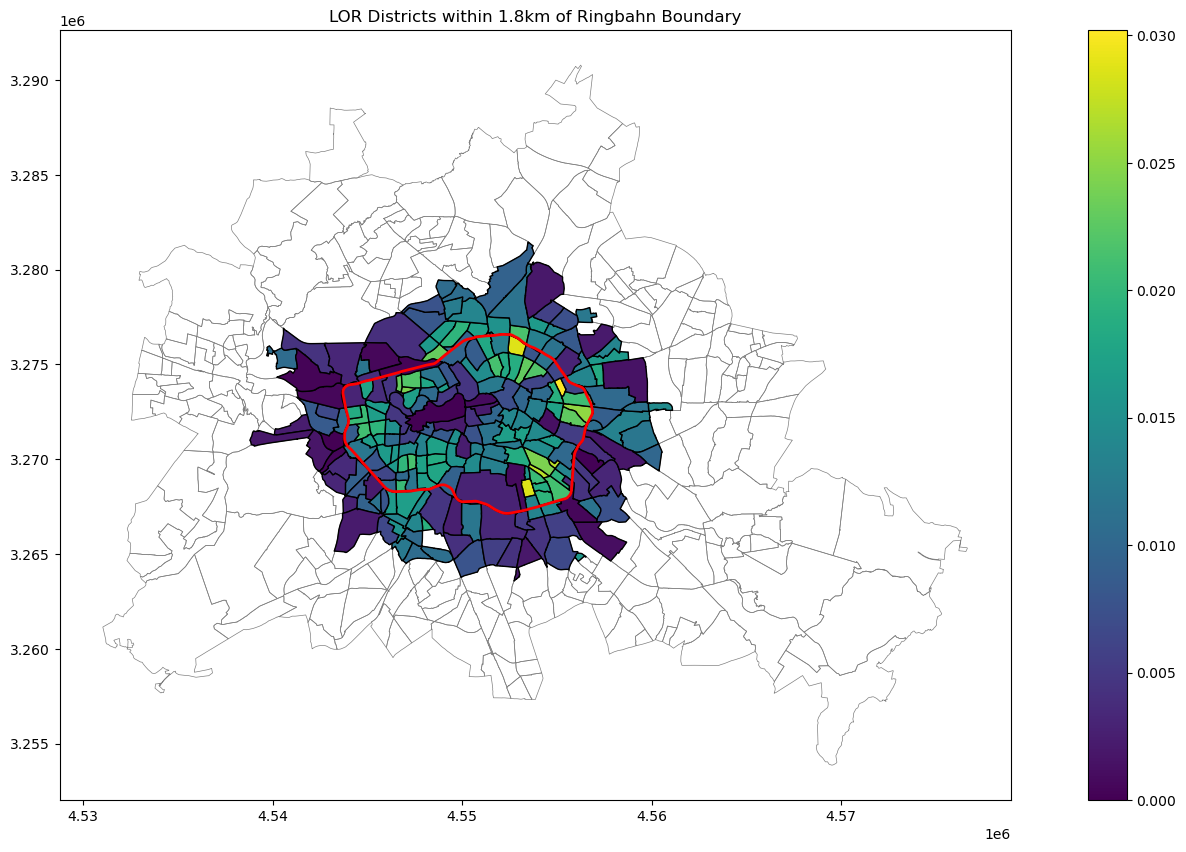

In [110]:
lor_ringbahn = lor_ringbahn[lor_ringbahn['selected']].copy()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20, 10))
lor_3035.plot(ax=ax, edgecolor='gray', facecolor='none', linewidth=0.5)
lor_ringbahn.plot(ax=ax, column = "population_density", edgecolor='black', cmap='viridis', legend=True)
boundary_3035.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
ax.set_title(f'LOR Districts within {buffer_distance*10**(-3)}km of Ringbahn Boundary')
plt.show()


In [111]:
from hotelling.spatial.census import build_full_grid

full = build_full_grid(boundary = lor_ringbahn, zensus = zensus)

# Save the full grid (to processed)

full.to_parquet(PATH_PROCESSED / 'pop_grid.parquet', index=False)

<Axes: >

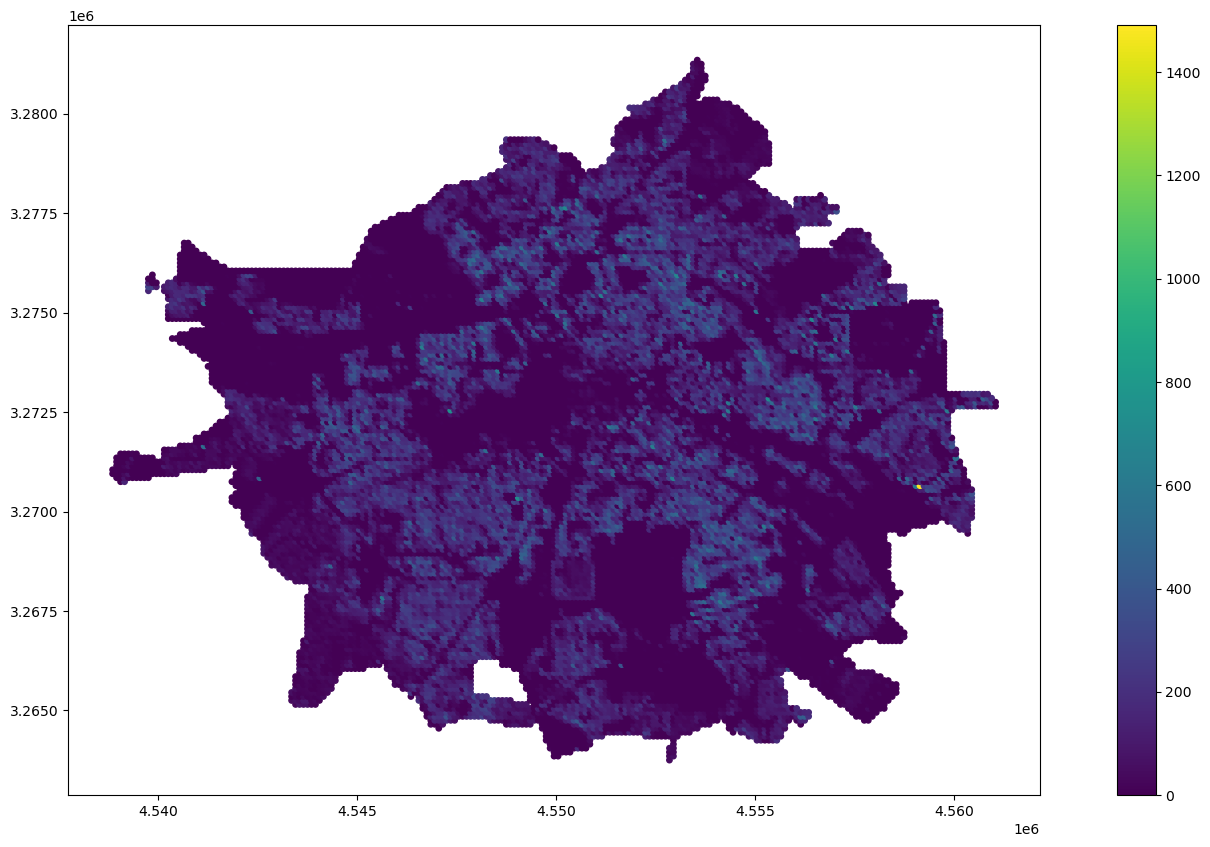

In [112]:
full.plot(column='Einwohner', cmap='viridis', legend=True, figsize=(20, 10), markersize=15)